# Notebook 02 – Veri Görselleştirme

Bu notebook’ta Amasya iline bağlı Hamamözü, Gümüşhacıköy ve Göynücek ilçelerine ait
elektrik tüketim ve tahsilat verileri görselleştirme teknikleriyle analiz edilmiştir.

Amaç, ilçeler arası farkları, mevsimsel tüketim eğilimlerini ve müşteri davranışlarını
grafikler aracılığıyla daha anlaşılır hale getirmektir.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
file_path = "/content/elektrik_veri.xlsx"
xls = pd.ExcelFile(file_path)
xls.sheet_names


['Tahsilat', 'Tahsilat 1', 'Tahakkuk', 'Tahakkuk 1', 'Tahakkuk 2']

In [7]:
df_tahakkuk = pd.read_excel(xls, sheet_name="Tahakkuk")
df_tahakkuk_1 = pd.read_excel(xls, sheet_name="Tahakkuk 1")
df_tahakkuk_2 = pd.read_excel(xls, sheet_name="Tahakkuk 2")


In [8]:
df_tahakkuk_all = pd.concat(
[df_tahakkuk, df_tahakkuk_1, df_tahakkuk_2],
   axis=0,
    ignore_index=True)


In [9]:
hamamozu = df_tahakkuk_all[df_tahakkuk_all["ilce"] == "HAMAMÖZÜ"]
gumushacikoy = df_tahakkuk_all[df_tahakkuk_all["ilce"] == "GÜMÜŞHACIKÖY"]
goynucek = df_tahakkuk_all[df_tahakkuk_all["ilce"] == "GÖYNÜCEK"]


In [10]:
ham_counts = hamamozu["Hesap Sınıfı"].value_counts()
gum_counts = gumushacikoy["Hesap Sınıfı"].value_counts()
goy_counts = goynucek["Hesap Sınıfı"].value_counts()


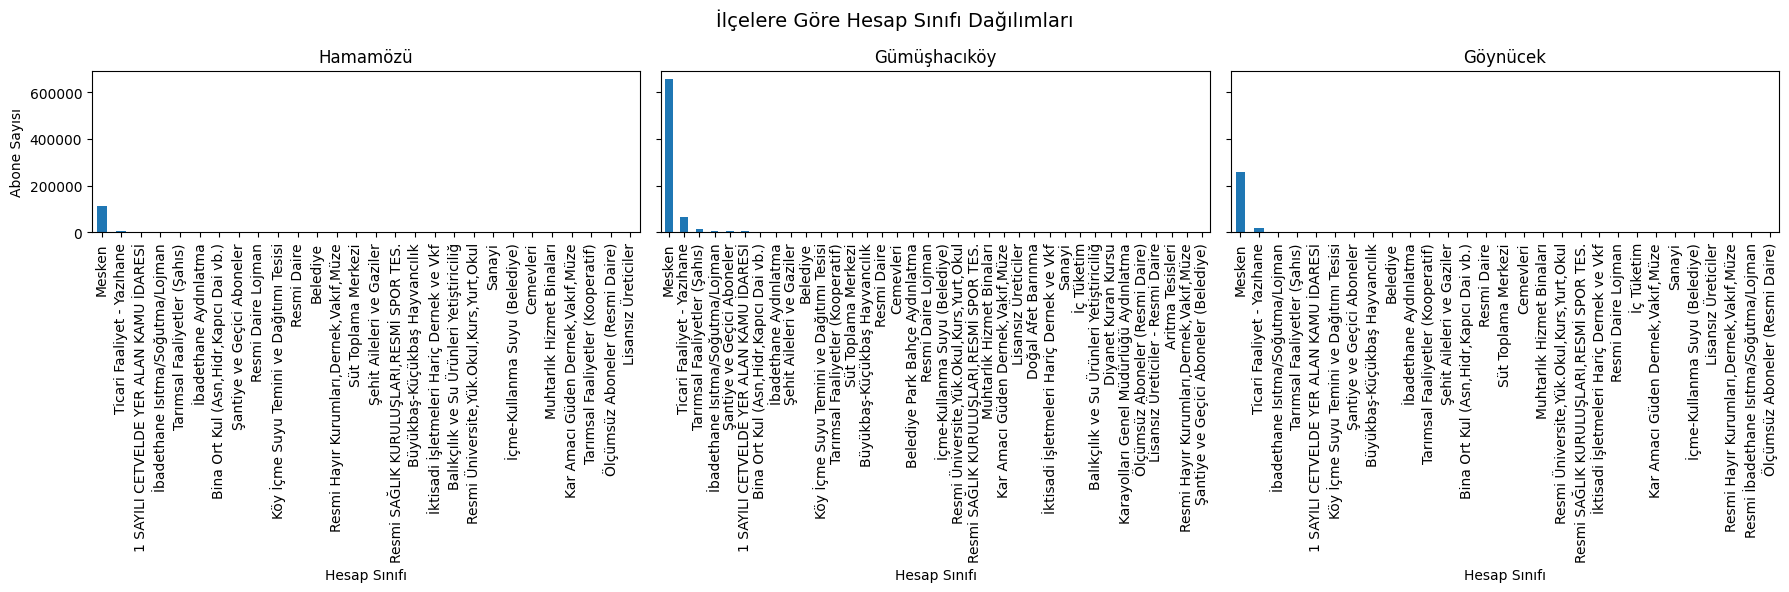

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

ham_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Hamamözü")
axes[0].set_ylabel("Abone Sayısı")

gum_counts.plot(kind="bar", ax=axes[1])
axes[1].set_title("Gümüşhacıköy")

goy_counts.plot(kind="bar", ax=axes[2])
axes[2].set_title("Göynücek")

plt.suptitle("İlçelere Göre Hesap Sınıfı Dağılımları", fontsize=14)
plt.tight_layout()
plt.show()


### Grafik Yorumu: İlçelere Göre Hesap Sınıfı Dağılımları

Grafik incelendiğinde üç ilçede de **Mesken** hesap sınıfının açık ara en yüksek abone sayısına sahip olduğu görülmektedir. Bu durum, analiz edilen bölgelerde elektrik tüketiminin ağırlıklı olarak buradan kaynaklı olduğunu göstermektedir.

**Gümüşhacıköy** ilçesi, hem toplam abone sayısı hem de hesap sınıfı çeşitliliği açısından diğer ilçelerden belirgin şekilde ayrışmaktadır.

**Hamamözü** ve **Göynücek** ilçelerinde ise hesap sınıfı dağılımının daha sınırlı olduğu, özellikle mesken dışı aboneliklerin sayıca düşük kaldığı gözlemlenmektedir.

Genel olarak değerlendirildiğinde, ilçeler arasındaki hesap sınıfı dağılım farklılıkları, ilerleyen analizlerde tüketim miktarları ve tahsilat davranışları üzerinde belirleyici bir faktör olarak ele alınmalıdır.


## Aylık Ortalama Elektrik Tüketimi ve Mevsimsel Eğilimler

Bu analizde Hamamözü, Gümüşhacıköy ve Göynücek ilçelerine ait elektrik tüketim verileri
aylık bazda ortalamaya dönüştürülerek incelenmiştir.

Amaç, ilçelere göre tüketim trendlerini karşılaştırmak ve
mevsimsel dalgalanmaların varlığını görsel olarak ortaya koymaktır.

In [12]:
df_tahakkuk_all["mali_yil_donem"] = pd.to_datetime(df_tahakkuk_all["mali_yil_donem"])
df_tahakkuk_all["ay"] = df_tahakkuk_all["mali_yil_donem"].dt.month


In [13]:
aylik_ortalama = (
 df_tahakkuk_all
  .groupby(["ilce", "ay"])["kwh"]
   .mean()
    .reset_index())


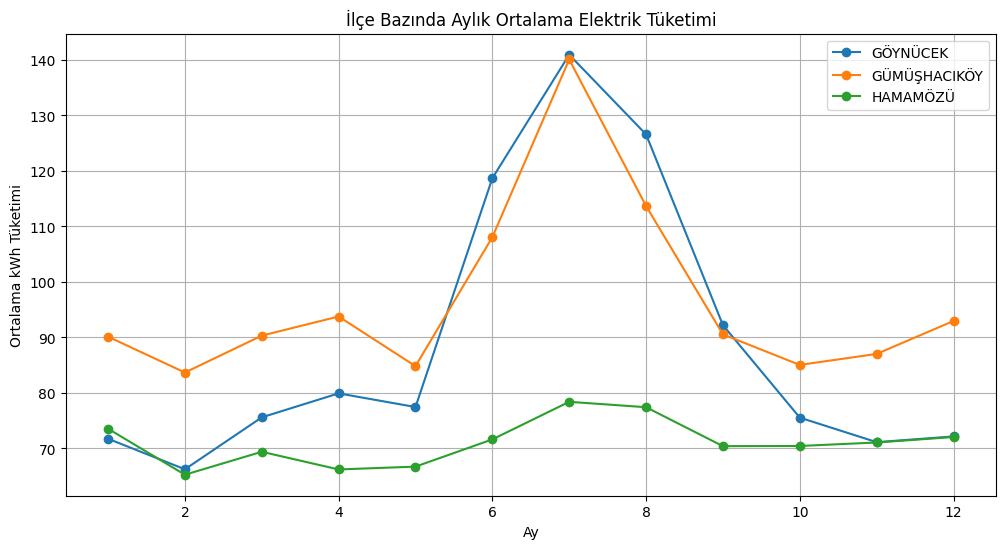

In [16]:
plt.figure(figsize=(12, 6))
for ilce in aylik_ortalama["ilce"].unique():
    veri = aylik_ortalama[aylik_ortalama["ilce"] == ilce]
    plt.plot(veri["ay"], veri["kwh"], marker="o", label=ilce)
plt.xlabel("Ay")
plt.ylabel("Ortalama kWh Tüketimi")
plt.title("İlçe Bazında Aylık Ortalama Elektrik Tüketimi")
plt.legend()
plt.grid(True)
plt.show()


### Grafik Yorumu: İlçe Bazında Aylık Ortalama Elektrik Tüketimi

Grafik incelendiğinde üç ilçede de elektrik tüketiminin yıl içerisinde belirgin
mevsimsel dalgalanmalar gösterdiği görülmektedir. Özellikle yaz aylarında
(6–8. aylar arası) ortalama tüketim seviyelerinde belirgin bir artış dikkat çekmektedir.

**Gümüşhacıköy** ve **Göynücek** ilçeleri, yılın ortasında benzer bir tüketim zirvesi
sergilemekte olup her iki ilçede de en yüksek ortalama tüketim değerleri
7. ay civarında gerçekleşmiştir. Bu durum, yaz döneminde artan elektrik talebinin
bu ilçelerde daha belirgin olduğunu göstermektedir.

**Hamamözü** ilçesinde ise tüketim seviyelerinin yıl boyunca daha istikrarlı
seyrettiği ve mevsimsel dalgalanmaların diğer iki ilçeye kıyasla sınırlı olduğu
gözlemlenmektedir. Bu durum, Hamamözü’nde elektrik tüketiminin ağırlıklı olarak
konut kaynaklı ve daha dengeli bir yapıya sahip olduğunu düşündürmektedir.

Genel olarak değerlendirildiğinde, ilçeler arasındaki mevsimsel tüketim farkları,
gelecek analizlerde kapasite planlaması ve talep tahmini çalışmalarında
dikkate alınması gereken önemli bir göstergedir.


## Tahsilat Verilerinin İlçe ve Şube Bazında Dağılımı

Bu bölümde tahsilat verileri ilçe ve şube bazında incelenmiştir.

Amaç, tahsilat işlemlerinin coğrafi ve operasyonel dağılımını analiz ederek hangi ilçelerde ve hangi şubelerde tahsilat yoğunluğunun daha yüksek olduğunu görsel olarak ortaya koymaktır.


In [18]:
df_tahsilat = pd.read_excel(xls, sheet_name="Tahsilat")


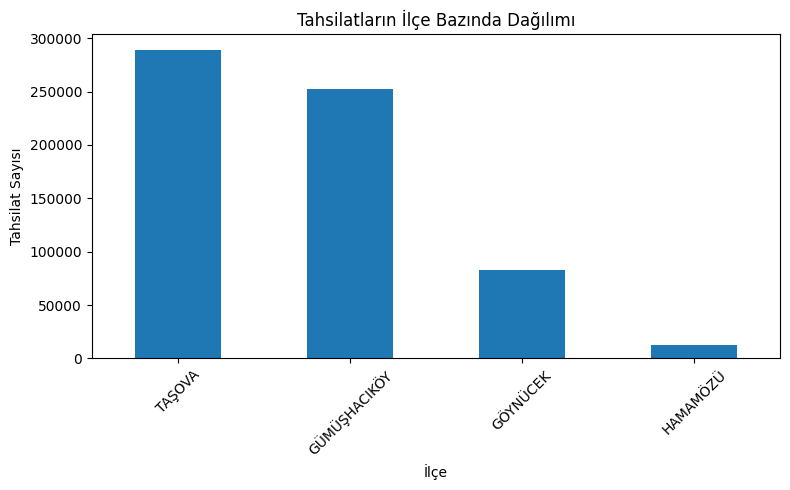

In [21]:
ilce_tahsilat = df_tahsilat["İlçe"].value_counts()
plt.figure(figsize=(8, 5))
ilce_tahsilat.plot(kind="bar")
plt.title("Tahsilatların İlçe Bazında Dağılımı")
plt.xlabel("İlçe")
plt.ylabel("Tahsilat Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Grafik Yorumu: Tahsilatların İlçe Bazında Dağılımı

Grafik incelendiğinde tahsilat işlemlerinin ilçeler arasında eşit dağılmadığı görülmektedir. **Taşova** ilçesi, en yüksek tahsilat işlem sayısına sahip ilçe
olarak öne çıkarken, **Gümüşhacıköy** ikinci sırada yer almaktadır.

**Göynücek** ve özellikle **Hamamözü** ilçelerinde tahsilat işlem sayılarının
görece düşük olduğu gözlemlenmektedir. Bu durum, bu ilçelerdeki abone sayısının
daha sınırlı olması veya tahsilat işlemlerinin farklı kanallar üzerinden
gerçekleşmesiyle ilişkili olabilir.

İlçe bazındaki bu farklılıklar, tahsilat operasyonlarının planlanması ve
kaynak dağılımı açısından dikkate alınması gereken önemli bir göstergedir.


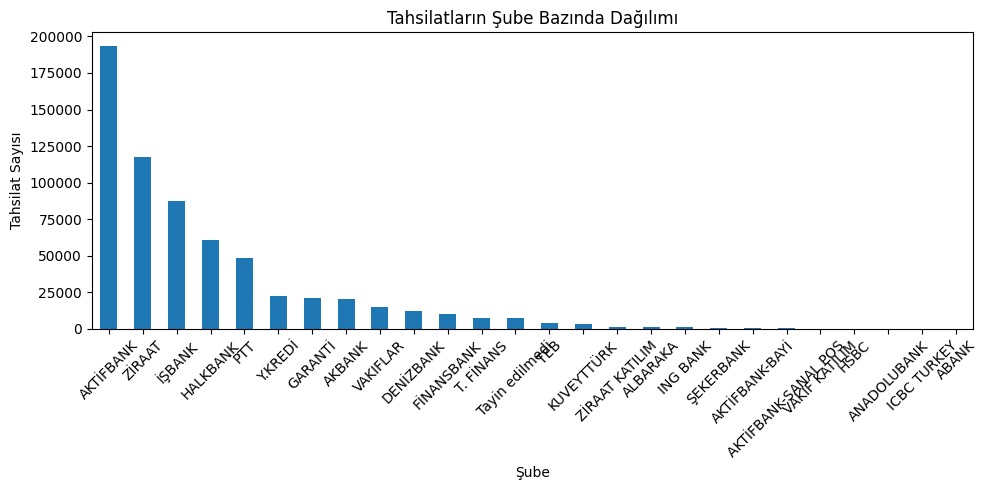

In [22]:
sube_tahsilat = df_tahsilat["Şube"].value_counts()
plt.figure(figsize=(10, 5))
sube_tahsilat.plot(kind="bar")
plt.title("Tahsilatların Şube Bazında Dağılımı")
plt.xlabel("Şube")
plt.ylabel("Tahsilat Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Grafik Yorumu: Tahsilatların Şube Bazında Dağılımı

Şube bazında tahsilat dağılımı incelendiğinde, tahsilat işlemlerinin belirli
şubelerde yoğunlaştığı açıkça görülmektedir. Özellikle **Aktifbank**, **Ziraat
Bankası**, **İş Bankası** ve **Halkbank** gibi şubelerin toplam tahsilat işlemlerinin büyük bir bölümünü gerçekleştirdiği anlaşılmaktadır.

Diğer şubelerde ise tahsilat işlem sayılarının oldukça düşük seviyelerde kaldığı
gözlemlenmektedir. Bu durum, müşterilerin tahsilat işlemlerinde sınırlı sayıda
kanalı tercih ettiğini ve işlem yoğunluğunun belirli finansal kuruluşlar üzerinde toplandığını göstermektedir.

Bu bulgu, tahsilat süreçlerinin optimizasyonu ve anlaşmalı şube yönetimi açısından stratejik kararlar alınmasına katkı sağlayabilir.


## Zamanında ve Geç Ödeme Dağılımı

Bu bölümde Tahsilat 1 verisi kullanılarak ödemelerin,
son ödeme tarihine göre hangi zaman aralıklarında
gerçekleştiği analiz edilmiştir.

Amaç, zamanında yapılan tahsilatlar ile gecikmeli tahsilatlar
arasındaki dağılımı özetleyerek tahsilat performansını
genel hatlarıyla değerlendirmektir.



In [29]:
df_tahsilat1 = pd.read_excel(xls, sheet_name="Tahsilat 1")


In [31]:
zamaninda_odeme = (
    df_tahsilat1["Son Ödeme Tarihinden Önceki Tahsilat"].sum() +
    df_tahsilat1["Son Ödeme Tarihindeki Tahsilat"].sum()
    )


In [32]:
gec_odeme_sutunlari = [
    "Son Ödeme (1)", "Son Ödeme (2)", "Son Ödeme (3)", "Son Ödeme (4)",
    "Son Ödeme (5)", "Son Ödeme (6-10)", "Son Ödeme (10-20)",
    "Son Ödeme (20-30)", "Son Ödeme (30-60)", "Son Ödeme (60-90)",
    "Son Ödeme (90-120)", "Son Ödeme (120-150)",
    "Son Ödeme (150-180)", "Son Ödeme (180+)"
]
gec_odeme = df_tahsilat1[gec_odeme_sutunlari].sum().sum()


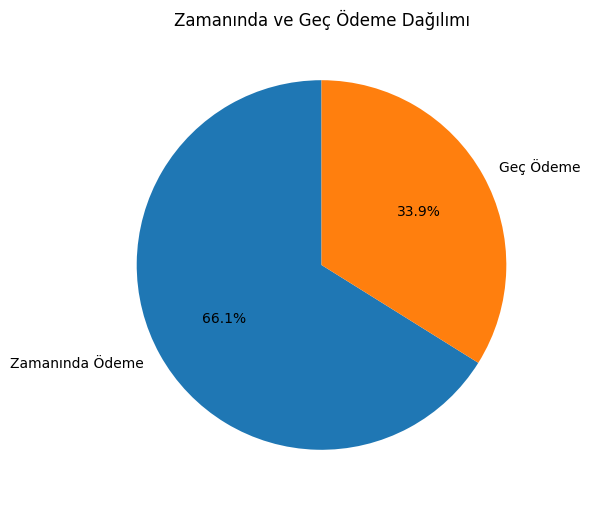

In [33]:
plt.figure(figsize=(6, 6))
plt.pie(
    [zamaninda_odeme, gec_odeme],
    labels=["Zamanında Ödeme", "Geç Ödeme"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Zamanında ve Geç Ödeme Dağılımı")
plt.show()


### Grafik Yorumu: Zamanında ve Geç Ödeme Dağılımı

Tahsilat 1 verisine dayalı analiz sonuçlarına göre, toplam tahsilatların
yaklaşık **%66,1’i zamanında**, **%33,9’u ise gecikmeli** olarak
gerçekleşmiştir.

Zamanında ödeme oranının üçte ikinin üzerinde olması, genel tahsilat
performansının olumlu olduğunu göstermektedir. Ancak gecikmeli ödemelerin
yaklaşık üçte birlik bir paya sahip olması, tahsilat süreçlerinde
iyileştirme potansiyeli bulunduğuna işaret etmektedir.

Bu bulgu, özellikle gecikmeli ödeme segmentlerinin daha detaylı
incelenmesi ve erken ödeme teşvikleri gibi
önleyici aksiyonların değerlendirilmesi açısından önemli bir gösterge
niteliğindedir.


## Elektrik Tüketimi Dağılımı ve Aykırı Değer Analizi

Bu bölümde tüm ilçeleri kapsayan kWh tüketim verisinin dağılımı
incelenmiş ve aykırı (uç) değerler görselleştirilmiştir.

Amaç, tüketim verisinin genel yapısını anlamak ve olağandışı
tüketim seviyelerini tespit etmektir.

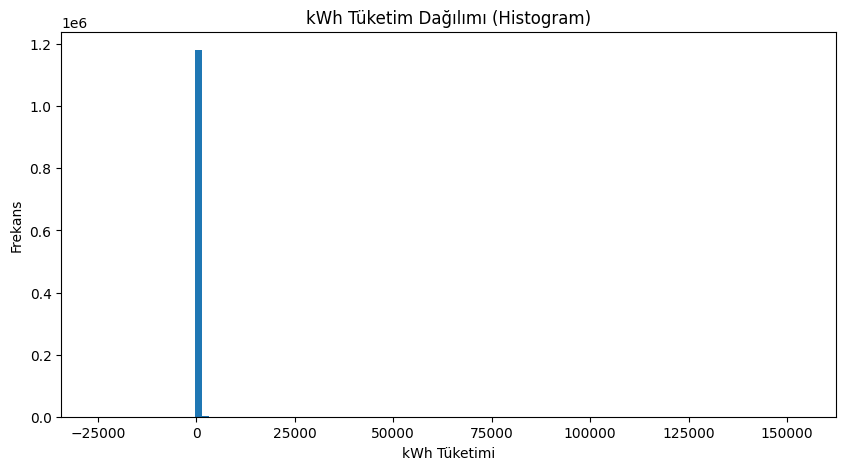

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(df_tahakkuk_all["kwh"], bins=100)
plt.xlabel("kWh Tüketimi")
plt.ylabel("Frekans")
plt.title("kWh Tüketim Dağılımı (Histogram)")
plt.show()

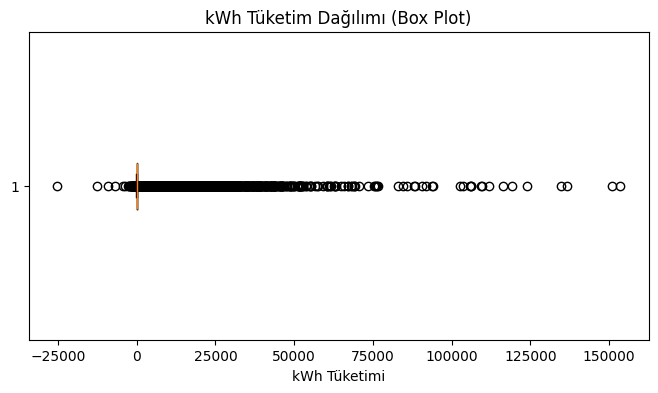

In [35]:
plt.figure(figsize=(8, 4))
plt.boxplot(df_tahakkuk_all["kwh"], vert=False)
plt.xlabel("kWh Tüketimi")
plt.title("kWh Tüketim Dağılımı (Box Plot)")
plt.show()


### Grafik Yorumu: kWh Tüketim Dağılımı ve Aykırı Değer Analizi

Histogram incelendiğinde, 0 kWh tüketim değerinin yalnızca tekil bir gözleme karşılık geldiği ve veri setinde belirgin bir yoğunluk oluşturmadığı
görülmektedir.

Box plot analizi, elektrik tüketim değerlerinin büyük ölçüde **0 ile 50.000 kWh** aralığında yoğunlaştığını ortaya koymaktadır. Bu aralık, veri setindeki abonelerin büyük çoğunluğunun tipik tüketim seviyelerini temsil etmektedir.
**50.000 – 75.000 kWh** aralığında ise tüketim değerlerinin görece daha seyrek olduğu, bu seviyelerin sınırlı sayıda yüksek tüketimli aboneye ait olduğu görülmektedir. Bu değerler aykırı tüketim davranışlarına işaret edebileceğinden, ilerleyen analizlerde bu grubun ayrı olarak incelenmesi faydalı olabilir.

Genel olarak değerlendirildiğinde, kWh tüketim dağılımının sağa çarpık bir yapı sergilediği ve az sayıda yüksek tüketim değerinin toplam dağılım üzerinde etkili olduğu anlaşılmaktadır.
